# Voile PY — lw = 1.70 m  |  RPA 2024
Vérification complète d'un voile de contreventement rectangulaire selon le chapitre 7 de l'RPA 2024.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from engine import (
    WallGeometry, Materials, LoadCombo,
    RebarConfig, ConfinedArea,
    plot_stress_strain,
    run_ductility, make_ductility_figure,
    run_phase1, build_envelope_table, make_materials,
    compute_nm_curves, run_phase4, run_phase5,
    make_nm_figure, make_section_figure,
)

plt.rcParams.update({
    'figure.dpi':        130,
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F8F7F4',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
    'axes.titlesize':    12,
    'axes.titleweight':  'bold',
    'axes.labelsize':    10,
})
print('Imports OK')

Imports OK


---
## 1. Données d'entrée

In [2]:
# ── Géométrie ───────────────────────────────────────────────────────────────
geom = WallGeometry(
    lw    = 1.70,   # longueur du voile [m]
    bw    = 0.30,   # épaisseur [m]
    hw    = 30.60,  # hauteur totale de la structure [m]
    he    = 3.06,   # hauteur libre d'un niveau [m]
    cover = 30.0,   # enrobage [mm]
)

# ── Matériaux ────────────────────────────────────────────────────────────────
mat = Materials(
    fc28   = 30.0,
    fyk    = 500.0,
    Es     = 200_000.0,
    eps_su = 0.05,
)

# ── Combinaisons de charges (ETABS — Pier Forces) ───────────────────────────
combos = [
    LoadCombo('C1', N_ed=-2725.0, M_base=725.0,  M_top=233.0),
    LoadCombo('C2', N_ed=-3016.0, M_base=820.0,  M_top=235.0),
]

print(f'Voile  lw={geom.lw:.2f} m  bw={geom.bw:.2f} m  hw={geom.hw:.1f} m  he={geom.he:.2f} m')
print(f'fc28={mat.fc28:.0f} MPa   fyk={mat.fyk:.0f} MPa')
print(f'Nombre de niveaux : {geom.n_storeys}')

Voile  lw=1.70 m  bw=0.30 m  hw=30.6 m  he=3.06 m
fc28=30 MPa   fyk=500 MPa
Nombre de niveaux : 10


---
## 2. Lois de comportement des matériaux

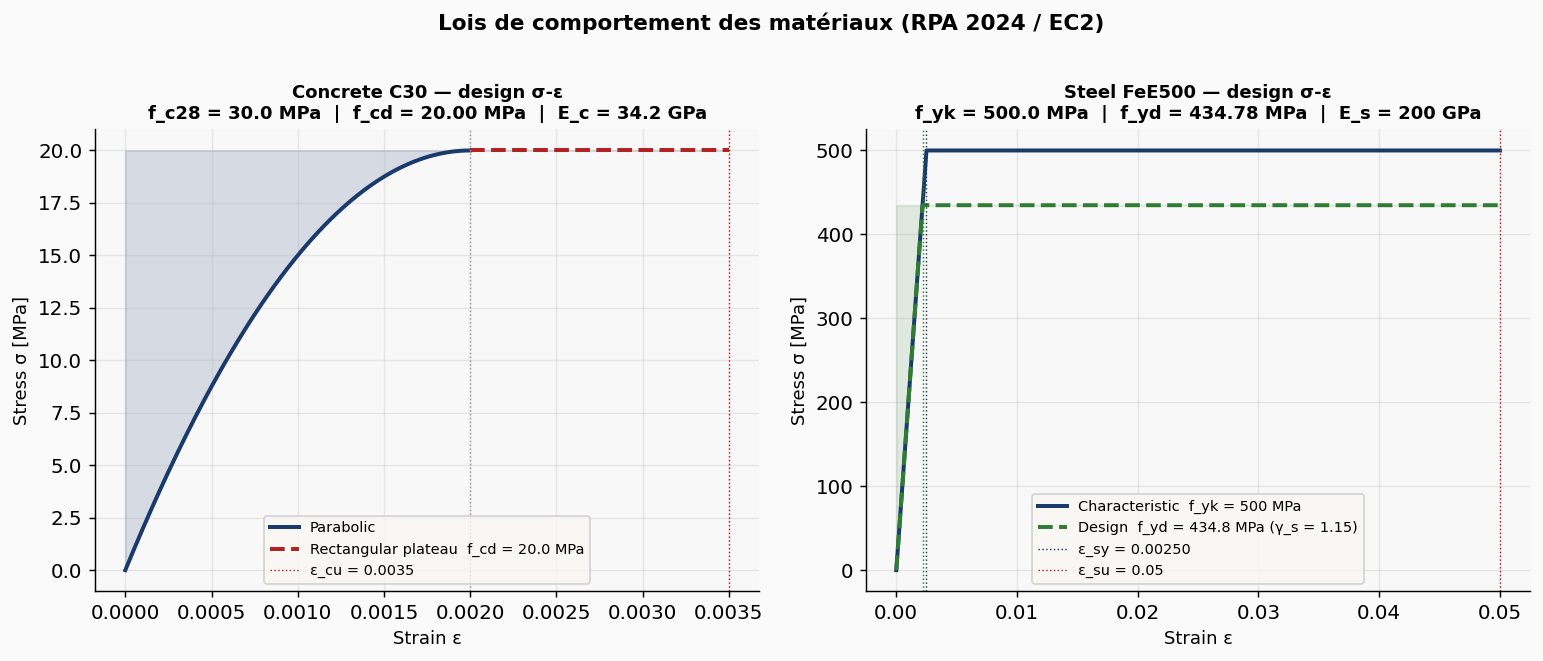

In [3]:
fig_ss = plot_stress_strain(mat)
plt.show()

---
## 3. Phase 1 — Vérifications préliminaires (§7.7.2 – §7.7.3)

In [4]:
p1 = run_phase1(geom, mat, combos)

print('=' * 55)
print('PHASE 1 — Vérifications préliminaires')
print('=' * 55)
print(f'  bw = {p1.bw*100:.0f} cm   bw_min = {p1.bw_min*100:.1f} cm   → {"OK" if p1.bw_ok else "NON OK"}')
print(f'  lw = {p1.lw*100:.0f} cm   lw_min = {p1.lw_min*100:.1f} cm   → {"OK" if p1.lw_ok else "NON OK"}')
print()
print(f'  hcr  = max(lw, hw/6) = max({geom.lw:.2f}, {geom.hw/6:.2f}) = {p1.hcr:.2f} m')
print(f'  lc   = max(0.15·lw, 1.5·bw) = max({0.15*geom.lw:.3f}, {1.5*geom.bw:.3f}) = {p1.lc:.3f} m = {p1.lc*1000:.0f} mm')
print(f'  n_crit (niveaux dans la zone critique) = {p1.n_crit}')
print()
print('  Effort normal réduit ν_d :')
for chk in p1.nu_d_checks:
    print(f"    {chk['label']}  ν_d = {chk['nu_d']:.4f}  ≤ 0.40  → {'OK' if chk['ok'] else 'NON OK'}")

PHASE 1 — Vérifications préliminaires
  bw = 30 cm   bw_min = 15.3 cm   → OK
  lw = 170 cm   lw_min = 120.0 cm   → OK

  hcr  = max(lw, hw/6) = max(1.70, 5.10) = 5.10 m
  lc   = max(0.15·lw, 1.5·bw) = max(0.255, 0.450) = 0.450 m = 450 mm
  n_crit (niveaux dans la zone critique) = 2

  Effort normal réduit ν_d :
    C1  ν_d = 0.1781  ≤ 0.40  → OK
    C2  ν_d = 0.1971  ≤ 0.40  → OK


---
## 4. Configurations d'armatures

In [5]:
# ── Éléments de rive : layout ConfinedArea (calqué sur l'éditeur ETABS) ─────
#    lc = 450 mm  →  on prend w = 450 mm, h = 300 mm (= bw)
#    Position automatique : centré à (lc/2) de chaque extrémité

be_critique = ConfinedArea(
    w          = 450,   # mm — largeur dans le sens lw (= lc)
    h          = 300,   # mm — épaisseur = bw
    corner_dia = 20,    # Ø barres de coin [mm]
    along_2    = 2,     # barres intermédiaires sur chaque face w
    along_3    = 1,     # barres intermédiaires sur chaque face h
    along_dia  = 20,    # Ø barres intermédiaires [mm]
)

be_courant = ConfinedArea(
    w          = 450,
    h          = 300,
    corner_dia = 16,
    along_2    = 1,
    along_3    = 1,
    along_dia  = 16,
)

configs = [
    RebarConfig(
        name        = 'C1 — Critique',
        confined    = be_critique,
        web_dia     = 12,
        web_spacing = 150,
    ),
    RebarConfig(
        name        = 'C2 — Courant',
        confined    = be_courant,
        web_dia     = 10,
        web_spacing = 200,
    ),
]

# Niveaux → configuration
# niveaux 1-2 : zone critique (hcr = 5.1 m, n_crit = 2)
# niveaux 3-10 : zone courante
storey_map = {1: 'C1 — Critique', 3: 'C2 — Courant'}

print('Configurations définies :')
for cfg in configs:
    ca = cfg.confined
    n_be = ca.total_bars()
    A_be = ca.As_total_mm2()
    print(f'  {cfg.name}')
    print(f'    BE  : {ca} → {n_be} barres/zone, As = {A_be/100:.1f} cm²/zone')
    A_web = 2 * (np.pi * cfg.web_dia**2 / 4)
    print(f'    Âme : Ø{cfg.web_dia} @ {cfg.web_spacing} mm')

Configurations définies :
  C1 — Critique
    BE  : ConfinedArea(w=450, h=300, corner=Ø20, along2=2×Ø20, along3=1×Ø20, hoop=Ø8) → 10 barres/zone, As = 31.4 cm²/zone
    Âme : Ø12 @ 150 mm
  C2 — Courant
    BE  : ConfinedArea(w=450, h=300, corner=Ø16, along2=1×Ø16, along3=1×Ø16, hoop=Ø8) → 8 barres/zone, As = 16.1 cm²/zone
    Âme : Ø10 @ 200 mm


---
## 5. Dessins des sections transversales

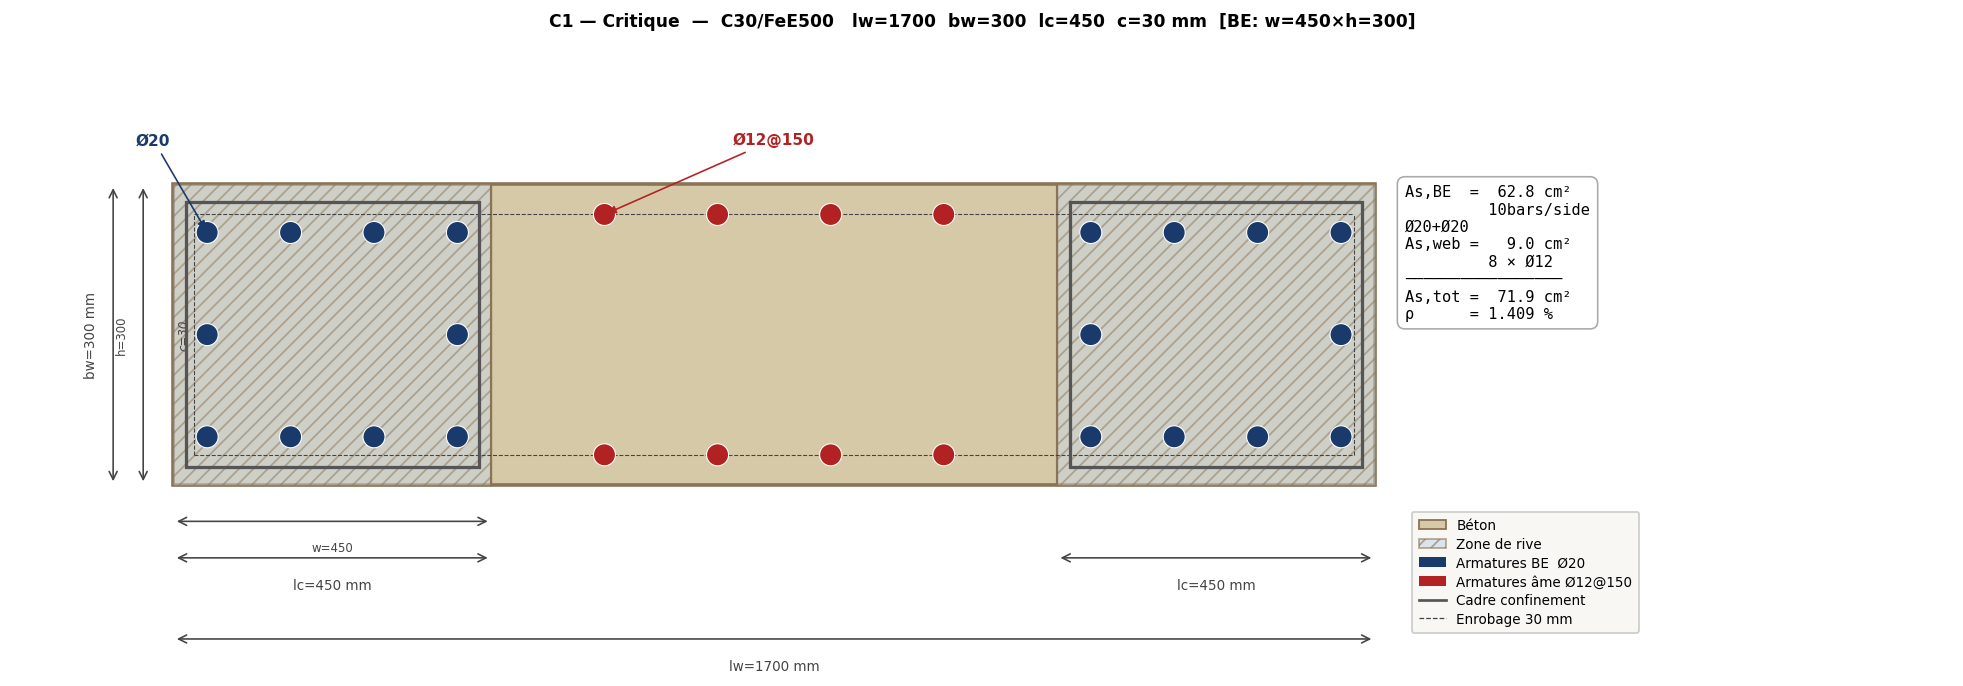

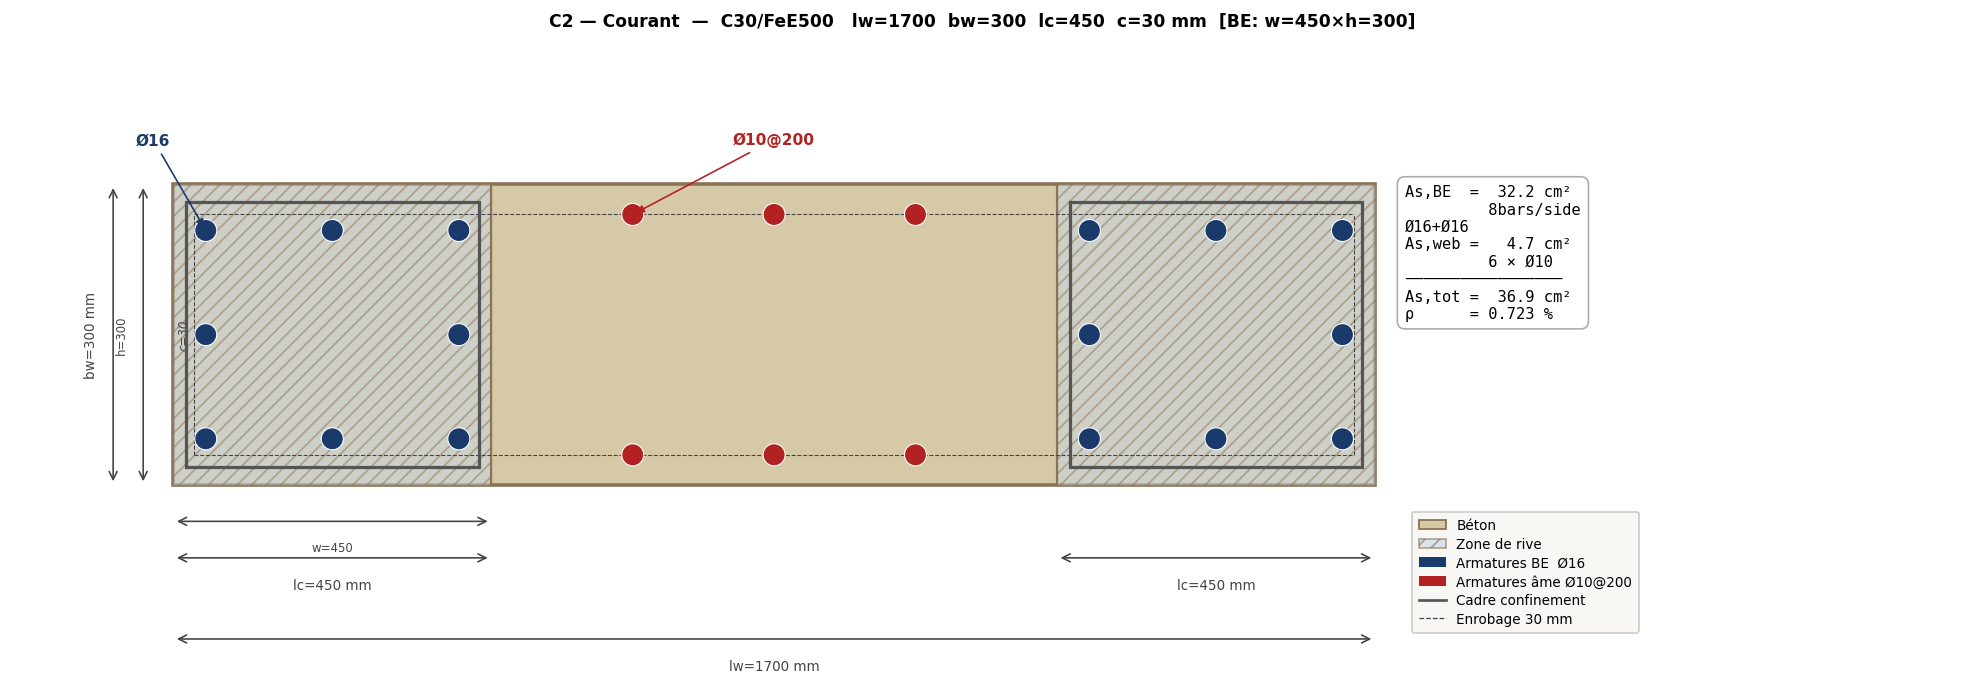

In [6]:
concrete_mat, steel_mat = make_materials(mat)

for cfg in configs:
    fig = make_section_figure(cfg, geom)
    plt.show()

---
## 6. Enveloppe de calcul décalée (§7.7.4)

In [ ]:
envelope = build_envelope_table(geom, combos)

rows = []
for row in envelope:
    rows.append({
        'Niveau': row['storey'],
        'z [m]':  round(row['z_m'], 2),
        **{f"Menv {c.label} [kN·m]": round(row[f'Menv_{c.label}'], 1) for c in combos},
        'Menv max [kN·m]': round(row['Menv_max'], 1),
    })
import pandas as pd
df_env = pd.DataFrame(rows)
print('Enveloppe de moment fléchissant décalée de hcr :')
print(df_env.to_string(index=False))

NameError: name 'pd' is not defined

---
## 7. Diagrammes N-M et vérification par niveau

In [ ]:
nm_curves = compute_nm_curves(geom, configs, concrete_mat, steel_mat, n_points=30)
storeys   = run_phase4(envelope, nm_curves, storey_map)

print('Vérification Menv ≤ MR par niveau :')
print(f"{'Niv':>4}  {'z [m]':>6}  {'Config':22}  {'Menv':>8}  {'MR':>8}  {'η':>6}  Statut")
print('-' * 75)
for r in storeys:
    print(f"{r.storey:>4}  {r.z_m:>6.2f}  {r.cfg_name:22}  "
          f"{r.Menv:>8.1f}  {r.MR:>8.1f}  {r.eta:>6.3f}  {r.status}")

all_ok = all(r.ok for r in storeys)
print()
print('Résultat global :', 'VÉRIFIÉ ✅' if all_ok else 'NON VÉRIFIÉ ❌')

In [ ]:
fig_nm = make_nm_figure(nm_curves, combos, storeys, geom)
plt.show()

---
## 8. Phase 5 — Confinement et ductilité globale (§7.7.5)

In [ ]:
cfg_base = next(c for c in configs if c.name == storey_map[1])
p5 = run_phase5(geom, mat, combos, cfg_base)

print('=' * 55)
print('PHASE 5 — Confinement (§7.7.5)')
print('=' * 55)
print(f'  ν_d          = {p5.nu_d:.4f}')
print(f'  ρ_v          = {p5.rho_v:.5f}  (ferraillage vertical âme)')
print(f'  ω_v          = {p5.omega_v:.4f}')
print(f'  μ_φ (forfait) = {p5.mu_phi:.1f}')
print(f'  α·ω_wd requis = {p5.omega_wd_req:.4f}  (min 0.12)')
print(f'  St_max        = {p5.St_max:.1f} mm  (espacement max étriers de confinement)')

---
## 9. Vérification ductilité locale §7.7.5 (eqs. 7.30 – 7.39)

In [ ]:
# Paramètres sismiques à adapter selon le spectre de site
T0  = 0.65    # période fondamentale T0 [s]  — à recalculer
T2  = 0.50    # période coin du spectre T2 [s]
R   = 3.0     # coefficient de comportement R (RPA 2024)
QF  = 1.25    # coefficient de surcharge Q_F
M_RD = 1200.0  # moment résistant à la base [kN·m]  — tiré du diagramme N-M

combo_gov = max(combos, key=lambda c: abs(c.N_ed))   # combo le plus défavorable

dr = run_ductility(
    geom=geom, mat=mat, combo=combo_gov, cfg_base=cfg_base,
    T0=T0, T2=T2, R=R, QF=QF, M_RD=M_RD,
)

print('=' * 55)
print('§7.7.5 — Ductilité locale')
print('=' * 55)
print(f'  Combo gouvernante  : {combo_gov.label}  (N_Ed = {combo_gov.N_ed:.0f} kN)')
print()
print(f'  ν_d               = {dr.nu_d:.4f}')
print(f'  ω_v               = {dr.omega_v:.4f}  (eq. 7.34)')
print(f'  μ_φ               = {dr.mu_phi:.3f}  (eq. 7.36)')
print(f'  α_n               = {dr.alpha_n:.4f}  (eq. 7.35)')
print(f'  α_s               = {dr.alpha_s:.4f}  (eq. 7.35)')
print(f'  α = α_n·α_s       = {dr.alpha:.4f}')
print()
print(f'  α·ω_wd requis     = {dr.omega_wd_req:.4f}  (eq. 7.30,  min 0.12)')
print(f'  α·ω_wd fourni     = {dr.omega_wd_prov:.4f}  → {"VÉRIFIÉ ✅" if dr.omega_wd_ok else "NON VÉRIFIÉ ❌"}')
print()
print(f'  ε_cu,c            = {dr.eps_cu_c:.5f}  (eq. 7.38)')
print(f'  x_u               = {dr.x_u:.2f} mm   (eq. 7.37)')
print(f'  l_c,calcul        = {dr.lc_calcul:.1f} mm  (eq. 7.39)')
print(f'  l_c,min           = {dr.lc_min:.1f} mm  = max(0.15·lw, 1.5·bw)')
print(f'  l_c,fourni        = {dr.lc_provided:.1f} mm  → {"VÉRIFIÉ ✅" if dr.lc_ok else "NON VÉRIFIÉ ❌"}')

In [ ]:
fig_duct = make_ductility_figure(dr, geom)
plt.show()

---
## 10. Bilan global

In [ ]:
print('=' * 55)
print('BILAN GLOBAL — Voile lw=1.70 m')
print('=' * 55)
print(f'  Géométrie (bw, lw)        : {"OK" if p1.bw_ok and p1.lw_ok else "NON OK"}')
print(f'  Effort normal réduit ν_d  : {"OK" if all(c["ok"] for c in p1.nu_d_checks) else "NON OK"}')
print(f'  Menv ≤ MR  (tous niveaux) : {"OK" if all_ok else "NON OK"}')
print(f'  α·ω_wd confinement        : {"OK" if dr.omega_wd_ok else "NON OK"}')
print(f'  l_c,calcul ≤ l_c,fourni   : {"OK" if dr.lc_ok else "NON OK"}')